# Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter
import time
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Device

In [2]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda:1


# Load Dataset

In [3]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

print("Fake shape:", fake_df.shape)
print("True shape:", true_df.shape)

# Add labels
fake_df["label"] = 1   # Fake
true_df["label"] = 0   # Real

# Merge and shuffle
df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Combine title + text
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")
df = df[["content", "label"]].copy()

print("Merged dataset shape:", df.shape)
print(df["label"].value_counts())

# Optional smaller subset for faster training
df = df.sample(10000, random_state=42).reset_index(drop=True)
print("Subset shape:", df.shape)

Fake shape: (23481, 4)
True shape: (21417, 4)
Merged dataset shape: (44898, 2)
label
1    23481
0    21417
Name: count, dtype: int64
Subset shape: (10000, 2)


# Text Cleaning

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_content"] = df["content"].apply(clean_text)

# Tokenization

In [5]:
def tokenize(text):
    return text.split()

df["tokens"] = df["clean_content"].apply(tokenize)
all_tokens = []
for tokens in df["tokens"]:
    all_tokens.extend(tokens)

word_counts = Counter(all_tokens)

MAX_VOCAB_SIZE = 10000
most_common_words = word_counts.most_common(MAX_VOCAB_SIZE - 2)

word2idx = {"<PAD>": 0, "<UNK>": 1}
for idx, (word, count) in enumerate(most_common_words, start=2):
    word2idx[word] = idx

idx2word = {idx: word for word, idx in word2idx.items()}

print("Vocabulary size:", len(word2idx))

Vocabulary size: 10000


# Encode and Padding

In [6]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(token, word2idx["<UNK>"]) for token in tokens]

df["sequence"] = df["tokens"].apply(lambda x: encode_tokens(x, word2idx))

MAX_LEN = 200

def pad_sequence(sequence, max_len):
    if len(sequence) < max_len:
        sequence = sequence + [0] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    return sequence

df["padded_sequence"] = df["sequence"].apply(lambda x: pad_sequence(x, MAX_LEN))

# Keep only useful columns
df = df[["padded_sequence", "label"]].copy()

# Custom Dataset

In [7]:
class FakeNewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

X = df["padded_sequence"].tolist()
y = df["label"].tolist()

dataset = FakeNewsDataset(X, y)
print("Dataset size:", len(dataset))

Dataset size: 10000


# Split Dataset

In [8]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8000
Validation size: 1000
Test size: 1000


# Data Load

In [9]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model

In [ ]:
class FakeNewsLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers, dropout):
        super(FakeNewsLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        out = self.dropout(hidden[-1])
        out = self.fc(out)
        return out.squeeze(1)

VOCAB_SIZE = len(word2idx)
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 1
NUM_LAYERS = 2
DROPOUT = 0.3

model = FakeNewsLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print(model)


# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Accuracy
def binary_accuracy(preds, y):
    probs = torch.sigmoid(preds)
    rounded = torch.round(probs)
    correct = (rounded == y).float()
    acc = correct.sum() / len(correct)
    return acc


# Train / Evaluate

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    epoch_loss = 0
    epoch_acc = 0
    
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        acc = binary_accuracy(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
    
    return epoch_loss / len(loader), epoch_acc / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = binary_accuracy(outputs, labels)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    
    return epoch_loss / len(loader), epoch_acc / len(loader)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        epoch_time = time.time() - start_time
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}")
        print(f"Val Loss   : {val_loss:.4f} | Val Acc   : {val_acc:.4f}")
        print(f"Epoch Time : {epoch_time:.2f} sec")
        print("-" * 50)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_fake_news_lstm.pth")
            print("Best model saved.\n")
    
    model.load_state_dict(best_model_wts)
    return model, history


FakeNewsLSTM(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [12]:
# Train model
NUM_EPOCHS = 5

model, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    NUM_EPOCHS
)

Epoch 1/5
Train Loss : 0.6158 | Train Acc : 0.6465
Val Loss   : 0.6305 | Val Acc   : 0.6449
Epoch Time : 2.68 sec
--------------------------------------------------
Best model saved.

Epoch 2/5
Train Loss : 0.5747 | Train Acc : 0.7131
Val Loss   : 0.6699 | Val Acc   : 0.5395
Epoch Time : 1.60 sec
--------------------------------------------------
Epoch 3/5
Train Loss : 0.6769 | Train Acc : 0.5354
Val Loss   : 0.6713 | Val Acc   : 0.5326
Epoch Time : 1.67 sec
--------------------------------------------------
Epoch 4/5
Train Loss : 0.6711 | Train Acc : 0.5627
Val Loss   : 0.6686 | Val Acc   : 0.5346
Epoch Time : 1.64 sec
--------------------------------------------------
Epoch 5/5
Train Loss : 0.6698 | Train Acc : 0.5749
Val Loss   : 0.6632 | Val Acc   : 0.5604
Epoch Time : 1.77 sec
--------------------------------------------------


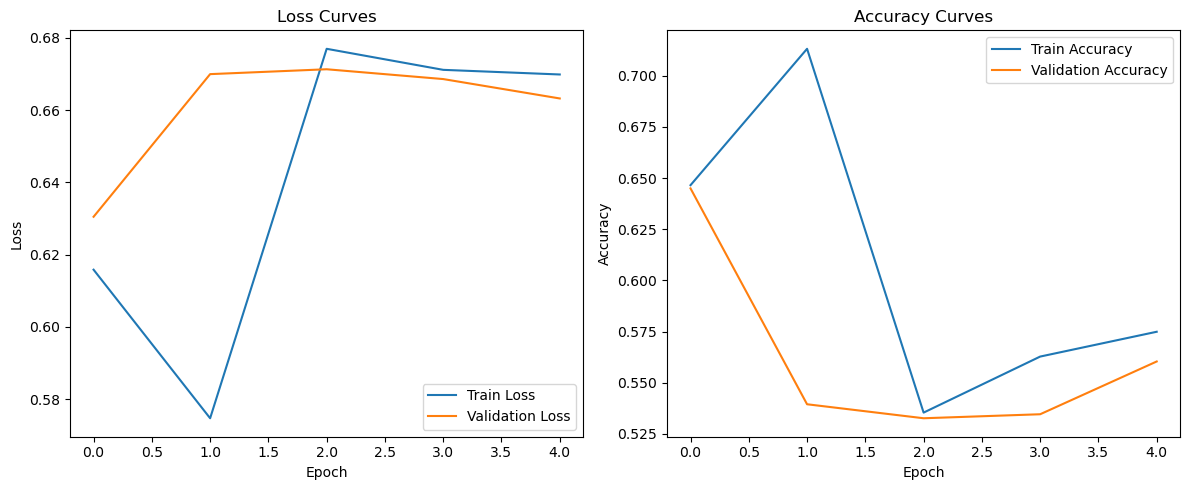

Test Loss: 0.6363
Test Accuracy: 0.6174


In [13]:
# Plot curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.tight_layout()
plt.savefig("fake_news_training_curves.png")
plt.show()


test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

In [14]:
#Prediction function
def predict_fake_news(text, model, word2idx, max_len, device):
    model.eval()
    
    text = clean_text(text)
    tokens = tokenize(text)
    sequence = encode_tokens(tokens, word2idx)
    padded = pad_sequence(sequence, max_len)
    
    tensor = torch.tensor(padded, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(tensor)
        prob = torch.sigmoid(output).item()
    
    prediction = "Fake" if prob >= 0.5 else "Real"
    
    return prediction, prob


sample_text_1 = """
Breaking news! Scientists confirm a secret miracle cure hidden by major pharmaceutical companies.
"""

prediction, prob = predict_fake_news(sample_text_1, model, word2idx, MAX_LEN, device)
print("\nExample 1")
print("Text:", sample_text_1)
print("Prediction:", prediction)
print("Probability:", prob)

sample_text_2 = """
The government released an official report today discussing economic growth and inflation trends over the last quarter.
"""

prediction, prob = predict_fake_news(sample_text_2, model, word2idx, MAX_LEN, device)
print("\nExample 2")
print("Text:", sample_text_2)
print("Prediction:", prediction)
print("Probability:", prob)


loaded_model = FakeNewsLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

loaded_model.load_state_dict(torch.load("best_fake_news_lstm.pth", map_location=device))
loaded_model.eval()

print("\nModel loaded successfully.")


Example 1
Text: 
Breaking news! Scientists confirm a secret miracle cure hidden by major pharmaceutical companies.

Prediction: Fake
Probability: 0.5011923909187317

Example 2
Text: 
The government released an official report today discussing economic growth and inflation trends over the last quarter.

Prediction: Real
Probability: 0.0458543635904789

Model loaded successfully.
